# Artificial Neural Network (ANN) with TensorFlow
- Using the **Iris dataset** to build a simple ANN for flower classification.

In [1]:
# 1. Import libraries
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

In [2]:
# Load dataset
iris = load_iris()
X = iris.data  
y = iris.target.reshape(-1, 1)  # Labels (0,1,2)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Build the ANN
- Input layer: 4 neurons (since we have 4 features)
- Hidden layer: 8 neurons, ReLU activation
- Output layer: 3 neurons, Softmax activation (as we have 3 labels)


In [3]:
model = Sequential([
    Dense(8, input_shape=(4,), activation='relu'),   # Hidden layer
    Dense(3, activation='softmax')                   # Output layer (3 classes)
])

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile the Model
- Loss: Categorical Crossentropy (since it’s multi-class classification)
- Optimizer: Adam
- Metrics: Accuracy


In [4]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
# Train the Model

history = model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test))


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9667 - loss: 0.2978 - val_accuracy: 1.0000 - val_loss: 0.2854
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9500 - loss: 0.2976 - val_accuracy: 0.9667 - val_loss: 0.2828
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9667 - loss: 0.2960 - val_accuracy: 1.0000 - val_loss: 0.2827
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9667 - loss: 0.2944 - val_accuracy: 1.0000 - val_loss: 0.2799
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9667 - loss: 0.2917 - val_accuracy: 1.0000 - val_loss: 0.2786
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9750 - loss: 0.2895 - val_accuracy: 1.0000 - val_loss: 0.2783
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9750 - loss: 0.2890 - val_accuracy: 1.0000 - val_loss: 0.2762
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9667 - loss: 0.2864 - val_accuracy: 1.0

In [22]:
## Evaluate the Model

loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.1656
Test Accuracy: 1.0000
Test Loss: 0.1656


In [23]:
# Make Predictions

predictions = model.predict(X_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:5], axis=1)

import pandas as pd
df = pd.DataFrame(predictions, columns=[f'Prob_Class_{i}' for i in range(predictions.shape[1])])
df['Predicted_Class'] = predicted_classes
df['True_Class'] = true_classes
display(df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


,Prob_Class_0,Prob_Class_1,Prob_Class_2,Predicted_Class,True_Class
0,1.119061e-03,0.789167,2.097140e-01,1,1
1,9.949301e-01,0.005069,8.814313e-07,0,0
2,3.214449e-09,0.023783,9.762173e-01,2,2
3,7.808743e-04,0.692338,3.068807e-01,1,1
4,5.586398e-04,0.791682,2.077591e-01,1,1


### Visualize Training History


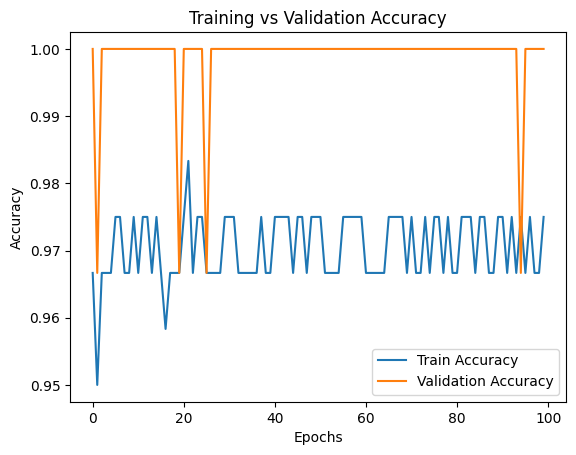

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()